In [1]:
print("all ok")

all ok


In [3]:
import sys, os

# Get project root — one level up from 'research_and_analyst'
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

print("Project root added to path:", project_root)

Project root added to path: c:\Users\aryan\automated-research-report-generation


In [4]:
from research_and_analysis.utils.model_loader import ModelLoader

C:\Users\aryan\automated-research-report-generation\research_and_analysis


In [390]:
model_loader = ModelLoader()

{"timestamp": "2025-11-29T21:34:07.126355Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2025-11-29T21:34:07.127364Z", "level": "warning", "event": "OPENAI_API_KEY is missing in environment variables"}
{"timestamp": "2025-11-29T21:34:07.128801Z", "level": "info", "event": "GOOGLE_API_KEY loaded successfully from environment"}
{"timestamp": "2025-11-29T21:34:07.129333Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"path": "C:\\Users\\aryan\\automated-research-report-generation\\research_and_analysis\\config\\configuration.yaml", "keys": ["embedding_model", "retriever", "llm"], "timestamp": "2025-11-29T21:34:07.131757Z", "level": "info", "event": "Configuration loaded successfully"}
{"config_keys": ["embedding_model", "retriever", "llm"], "timestamp": "2025-11-29T21:34:07.131757Z", "level": "info", "event": "YAML configuration loaded successfully"}


In [391]:
llm=model_loader.load_llm()

{"provider": "groq", "model": "llama-3.1-8b-instant", "timestamp": "2025-11-29T21:34:07.148220Z", "level": "info", "event": "Loading LLM"}
{"provider": "groq", "model": "llama-3.1-8b-instant", "timestamp": "2025-11-29T21:34:07.690448Z", "level": "info", "event": "LLM loaded successfully"}


In [392]:
llm.invoke("hi").content

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


'How can I assist you today?'

In [393]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [5]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage , SystemMessage
from langgraph.checkpoint.memory import MemorySaver

#health

Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
        ),

Analyst(
    name="Dr. Arun Verma",
    role="Ethics Researcher",
    affiliation="WHO",
    description="Explores ethical implications of AI in diagnostics."
),
Analyst(
    name="Ms. Priya Sharma",
    role="Policy Analyst",
    affiliation="Ministry of Health",
    description="Investigates AI policy and compliance frameworks."
)

In [395]:
class Analyst(BaseModel):
    name: str = Field(description="Name of the analyst.")
    role: str = Field(description="Role of the analyst in the context of the topic.")
    affiliation: str = Field(description="Primary affiliation of the analyst.")
    description: str = Field(description="Description of the analyst focus, concerns, and motives.")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"
    

In [396]:
analyst = Analyst(
    name="Aryan",
    role="genai eng",
    affiliation="AI Research LAB",
    description="I am genai developer"
    )

In [397]:
analyst.name

'Aryan'

In [398]:
analyst.role

'genai eng'

In [399]:
analyst.affiliation

'AI Research LAB'

In [400]:
print(analyst.persona)

Name: Aryan
Role: genai eng
Affiliation: AI Research LAB
Description: I am genai developer



In [401]:
class Perspectives(BaseModel):
       analysts: List[Analyst] = Field(description="Comprehensive list of analysts with their roles and affiliations.")

In [402]:
class GenerateAnalystsState(TypedDict):
    topic: str #research topic
    max_analysts: int # number of analyst
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    

In [403]:
GenerateAnalystsState(
    topic = "finance",
    max_analysts= 5,
    human_analyst_feedback= "give the real info",  
)

{'topic': 'finance',
 'max_analysts': 5,
 'human_analyst_feedback': 'give the real info'}

In [404]:
Analyst(
        name="Dr. Neha Patel",
        role="Medical Data Scientist",
        affiliation="Stanford Medicine",
        description="Focuses on predictive models for patient outcomes."
    ),

(Analyst(name='Dr. Neha Patel', role='Medical Data Scientist', affiliation='Stanford Medicine', description='Focuses on predictive models for patient outcomes.'),)

In [405]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [406]:
print([analyst_instructions.format(
        topic="education",
        max_analysts=4,
        human_analyst_feedback="please exaplain only on AI"
        
        )] + ["Generate the set of analysts."])

['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']


['You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:\n\n1. First, review the research topic:\neducation\n\n2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: \n\nplease exaplain only on AI\n\n3. Determine the most interesting themes based upon documents and / or feedback above.\n\n4. Pick the top 4 themes.\n\n5. Assign one analyst to each theme.', 'Generate the set of analysts.']

In [407]:
def create_analyst(state:GenerateAnalystsState):
    """
    it is creating my analyst
    
    """
    topic = state["topic"]
    max_analysts = state["max_analysts"]
    human_analyst_feedback = state.get("human_analyst_feedback","")
    
    structured_llm = llm.with_structured_output(Perspectives)
    
    system_messages = analyst_instructions.format(
        topic=topic,
        max_analysts=max_analysts,
        human_analyst_feedback=human_analyst_feedback
        
        )
    analysts = structured_llm.invoke([SystemMessage(content=system_messages)]+ [HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}
    

In [408]:
create_analyst(
    {'topic': 'health',
    'max_analysts': 2,
    'human_analyst_feedback': 'give the real info'}
    )

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Rachel Kim', role='Healthcare Economist', affiliation='Harvard University', description='Dr. Kim focuses on the economic impact of healthcare policies and their effects on patient outcomes.'),
  Analyst(name='Dr. Liam Chen', role='Public Health Specialist', affiliation='World Health Organization', description='Dr. Chen examines the social determinants of health and their influence on population health.'),
  Analyst(name='Dr. Sophia Patel', role='Health Informatics Expert', affiliation='Stanford University', description='Dr. Patel investigates the intersection of healthcare technology and patient outcomes.'),
  Analyst(name='Dr. Ethan Hall', role='Health Policy Analyst', affiliation='Centers for Disease Control and Prevention', description='Dr. Hall analyzes the effectiveness of healthcare policies and their impact on disease prevention.'),
  Analyst(name='Dr. Ava Martin', role='Global Health Researcher', affiliation='Bill and Melinda Gates Foundation', d

In [409]:
def human_feedback(state):
    """ No-op node that should be interrupted on """
    pass

In [410]:
def should_continue(state):
    feedback = (state.get("human_analyst_feedback") or "").strip().lower()
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END


In [411]:
# def should_continue(state):
#     """ Return the next node to execute """
#     human_analyst_feedback = state.get("human_analyst_feedback",None)
#     if human_analyst_feedback:
#         return "create_analyst"

In [412]:
from IPython.display import Image, display

## First Workflow

In [413]:
builder = StateGraph(GenerateAnalystsState)

In [414]:
builder.add_node("create_analyst",create_analyst)
builder.add_node("human_feedback", human_feedback)

In [415]:
builder.add_edge(START,"create_analyst")
builder.add_edge("create_analyst", "human_feedback")
builder.add_conditional_edges("human_feedback",
                        should_continue,
                        ["create_analyst",
                        END])

In [416]:
memory = MemorySaver()

In [417]:
graph = builder.compile(interrupt_before= ["human_feedback"],checkpointer= memory)

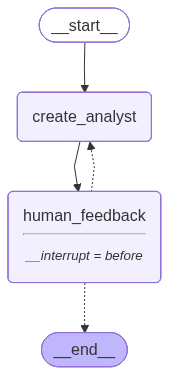

In [418]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [419]:
topic = "the benefits of adopting Langgraph as an agent framework"

In [420]:
max_analysts = 4

In [421]:
thread =  {"configurable":{"thread_id":1}}

In [422]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  
            
        

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Alex Chen
Affiliation: Langgraph Development Team
Role: Technical Lead
Description: Alex is a seasoned software engineer with expertise in agent frameworks and distributed systems. He is passionate about Langgraph's potential to revolutionize the field of artificial intelligence.
--------------------------------------------------
Name: Maya Patel
Affiliation: University of California, Berkeley
Role: Research Scientist
Description: Maya is a leading researcher in the field of natural language processing and its applications in AI. She is excited to explore the benefits of Langgraph in this domain.
--------------------------------------------------
Name: Ethan Kim
Affiliation: Langgraph Consulting
Role: Business Analyst
Description: Ethan is a business strategist with experience in implementing AI solutions in various industries. He is interested in the commercial potential of Langgraph as an agent framework.
--------------------------------------------------
Name: Liam Brown
Affil

In [423]:
state = graph.get_state(thread)

In [424]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'analysts': [Analyst(name='Alex Chen', role='Technical Lead', affiliation='Langgraph Development Team', description="Alex is a seasoned software engineer with expertise in agent frameworks and distributed systems. He is passionate about Langgraph's potential to revolutionize the field of artificial intelligence."), Analyst(name='Maya Patel', role='Research Scientist', affiliation='University of California, Berkeley', description='Maya is a leading researcher in the field of natural language processing and its applications in AI. She is excited to explore the benefits of Langgraph in this domain.'), Analyst(name='Ethan Kim', role='Business Analyst', affiliation='Langgraph Consulting', description='Ethan is a business strategist with experience in implementing AI solutions in various industries. He is interested in the commercial potential of Langgraph as an agent framework.'), A

In [425]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'analysts': [Analyst(name='Alex Chen', role='Technical Lead', affiliation='Langgraph Development Team', description="Alex is a seasoned software engineer with expertise in agent frameworks and distributed systems. He is passionate about Langgraph's potential to revolutionize the field of artificial intelligence."),
  Analyst(name='Maya Patel', role='Research Scientist', affiliation='University of California, Berkeley', description='Maya is a leading researcher in the field of natural language processing and its applications in AI. She is excited to explore the benefits of Langgraph in this domain.'),
  Analyst(name='Ethan Kim', role='Business Analyst', affiliation='Langgraph Consulting', description='Ethan is a business strategist with experience in implementing AI solutions in various industries. He is interested in the commercial potential of Langgraph as an agent framework.'),
  Analyst(name='

In [426]:
state.next

('human_feedback',)

In [427]:
# memory.storage

In [428]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f0cd6b2-37ce-6c8b-bfff-eb459c6528f9': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2025-11-29T21:34:08.906970+00:00\xa2id\xd9$1f0cd6b2-37ce-6c8b-bfff-eb459c6528f9\xb0channel_versions\x81\xa9__start__\xd9200000000000000000000000000000001.0.350799423321964\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f0cd6b2-37ce-6c8c-8000-552d261e28b3': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2025-11-29T21:34:08.906970+00:00\xa2id\xd9$1f0cd6b2-37ce-6c8c-8000-552d261e28b3\xb0channel_versions\x84\xa9__start__\xd9400000000000000000000000000000002.0.29566979742502253\xa5topic\xd9400000000000000000000000000000002.0.29566979742502253\xacmax_analysts\xd9400000000000000000000000000000002.0.29566979742502253\xb8branch:to:create_analyst\xd9400000000000000000000000000000002.0.29566979742502253\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start__

In [429]:
# import msgpack

# for thread_id, ns_dict in memory.storage.items():
#     print(f"\n Thread ID: {thread_id}")
    
#     # ns_dict = defaultdict(dict, {'': {...}})
#     for ns, ckpts in ns_dict.items():
#         print(f"  Namespace: '{ns}'")
        
#         # ckpts = dict of {checkpoint_id: (packed_values, packed_metadata, parent_id)}
#         for ckpt_id, (packed_values, packed_metadata, parent_id) in ckpts.items():
#             print(f"    Checkpoint ID: {ckpt_id}")
            
#             # Decode msgpack binary
#             values = msgpack.unpackb(packed_values[1], raw=False)
#             meta = msgpack.unpackb(packed_metadata[1], raw=False)
            
#             print(f"    Values keys: {list(values.keys())}")
#             print(f"    Parent ID: {parent_id}")
#             print(f"    Metadata: {meta}")
#             print("-" * 80)


In [430]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0cd6b2-3ca8-6d8a-8001-5b91d9881745'}}

In [431]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0cd6b2-3db2-6d0d-8002-a7060f93bea4'}}

In [432]:
for event in graph.stream({"topic":topic,
              "max_analysts":max_analysts},
             thread,
             stream_mode= "values"):
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Alex Chen
Affiliation: Langgraph Development Team
Role: Technical Lead
Description: Alex is a seasoned software engineer with expertise in agent frameworks and distributed systems. He is passionate about Langgraph's potential to revolutionize the field of artificial intelligence.
--------------------------------------------------
Name: Maya Patel
Affiliation: University of California, Berkeley
Role: Research Scientist
Description: Maya is a leading researcher in the field of natural language processing and its applications in AI. She is excited to explore the benefits of Langgraph in this domain.
--------------------------------------------------
Name: Ethan Kim
Affiliation: Langgraph Consulting
Role: Business Analyst
Description: Ethan is a business strategist with experience in implementing AI solutions in various industries. He is interested in the commercial potential of Langgraph as an agent framework.
--------------------------------------------------
Name: Liam Brown
Affil

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Alex Chen
Affiliation: Langgraph Startup Team
Role: Startup Enthusiast
Description: Alex is a startup founder who has successfully implemented Langgraph in their early-stage company. They focus on the benefits of adopting Langgraph for rapid prototyping and scalability.
--------------------------------------------------
Name: Maya Patel
Affiliation: Global Tech Inc.
Role: Enterprise Architect
Description: Maya is a seasoned enterprise architect who has implemented Langgraph in a large-scale enterprise application. She highlights the advantages of Langgraph for complex system integration and maintenance.
--------------------------------------------------
Name: Ethan Kim
Affiliation: Langgraph Research Lab
Role: AI Researcher
Description: Ethan is a researcher who has contributed to the development of Langgraph. He provides insights into the theoretical foundations and future directions of Langgraph as an agent framework.
--------------------------------------------------
Name: Sop

In [433]:
state = graph.get_state(thread)

In [434]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'max_analysts': 4, 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application', 'analysts': [Analyst(name='Alex Chen', role='Startup Enthusiast', affiliation='Langgraph Startup Team', description='Alex is a startup founder who has successfully implemented Langgraph in their early-stage company. They focus on the benefits of adopting Langgraph for rapid prototyping and scalability.'), Analyst(name='Maya Patel', role='Enterprise Architect', affiliation='Global Tech Inc.', description='Maya is a seasoned enterprise architect who has implemented Langgraph in a large-scale enterprise application. She highlights the advantages of Langgraph for complex system integration and maintenance.'), Analyst(name='Ethan Kim', role='AI Researcher', affiliation='Langgraph Research Lab', description='Ethan is a researcher who has contributed to the developmen

In [435]:
state.next

('human_feedback',)

In [436]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'max_analysts': 4,
 'human_analyst_feedback': 'add something from the startup perspective and focus on the latest enterprise application',
 'analysts': [Analyst(name='Alex Chen', role='Startup Enthusiast', affiliation='Langgraph Startup Team', description='Alex is a startup founder who has successfully implemented Langgraph in their early-stage company. They focus on the benefits of adopting Langgraph for rapid prototyping and scalability.'),
  Analyst(name='Maya Patel', role='Enterprise Architect', affiliation='Global Tech Inc.', description='Maya is a seasoned enterprise architect who has implemented Langgraph in a large-scale enterprise application. She highlights the advantages of Langgraph for complex system integration and maintenance.'),
  Analyst(name='Ethan Kim', role='AI Researcher', affiliation='Langgraph Research Lab', description='Ethan is a researcher who has contributed to the development of Langgraph

In [437]:
# import msgpack

# def get_all_checkpoints(memory, thread_id="1"):
#     """Return all checkpoints in chronological order for a thread."""
#     checkpoints = []
#     ns_dict = memory.storage.get(thread_id, {})
#     if "" not in ns_dict:
#         return []

#     for ckpt_id, (packed_values, packed_meta, parent_id) in ns_dict[""].items():
#         values = msgpack.unpackb(packed_values[1], raw=False)
#         meta = msgpack.unpackb(packed_meta[1], raw=False)
#         checkpoints.append({
#             "id": ckpt_id,
#             "parent": parent_id,
#             "topic": values.get("topic"),
#             "feedback": values.get("human_analyst_feedback"),
#             "analyst_count": len(values.get("analysts", [])),
#             "analysts": [a.model_dump() for a in values.get("analysts", [])],
#             "step": meta.get("step"),
#             "created_at": values.get("ts", None)
#         })
#     return checkpoints

# # Fetch all
# history = get_all_checkpoints(memory)

# # Sort by step (to get chronological order)
# history = sorted(history, key=lambda x: (x["step"] or 0))

# # Display neatly
# for h in history:
#     print(f"\nSTEP {h['step']} | CHECKPOINT {h['id']}")
#     print(f"Parent: {h['parent']}")
#     print(f"Topic: {h['topic']}")
#     print(f"Feedback: {h['feedback']}")
#     print(f"Analysts generated: {h['analyst_count']}")
#     print("-"*100)


In [438]:
# If we are satisfied, then we simply supply no feedback
further_feedack = ""

In [439]:
# 1) Get the latest state (you're paused at 'human_feedback')
state = graph.get_state(thread)

# 2) Use the exact config from that state (it already has thread_id, checkpoint_ns, checkpoint_id)
cfg = state.config

In [440]:
# 3) Update feedback at the 'human_feedback' node
#    Tip: if your TypedDict says `human_analyst_feedback: str`, prefer "" (empty string) over None
graph.update_state(cfg, {"human_analyst_feedback": ""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0cd6b2-43ba-6896-8006-4c21f1fa6e4a'}}

In [441]:
# 4) Verify it moved to END
final_state = graph.get_state(thread)
print(final_state.next)  # should be (END,)


()


In [442]:
analysts = final_state.values.get('analysts')

In [443]:
analysts

[Analyst(name='Alex Chen', role='Startup Enthusiast', affiliation='Langgraph Startup Team', description='Alex is a startup founder who has successfully implemented Langgraph in their early-stage company. They focus on the benefits of adopting Langgraph for rapid prototyping and scalability.'),
 Analyst(name='Maya Patel', role='Enterprise Architect', affiliation='Global Tech Inc.', description='Maya is a seasoned enterprise architect who has implemented Langgraph in a large-scale enterprise application. She highlights the advantages of Langgraph for complex system integration and maintenance.'),
 Analyst(name='Ethan Kim', role='AI Researcher', affiliation='Langgraph Research Lab', description='Ethan is a researcher who has contributed to the development of Langgraph. He provides insights into the theoretical foundations and future directions of Langgraph as an agent framework.'),
 Analyst(name='Sophia Rodriguez', role='DevOps Engineer', affiliation='Cloud Services Provider', description

In [444]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Alex Chen
Affiliation: Langgraph Startup Team
Role: Startup Enthusiast
Description: Alex is a startup founder who has successfully implemented Langgraph in their early-stage company. They focus on the benefits of adopting Langgraph for rapid prototyping and scalability.
--------------------------------------------------
Name: Maya Patel
Affiliation: Global Tech Inc.
Role: Enterprise Architect
Description: Maya is a seasoned enterprise architect who has implemented Langgraph in a large-scale enterprise application. She highlights the advantages of Langgraph for complex system integration and maintenance.
--------------------------------------------------
Name: Ethan Kim
Affiliation: Langgraph Research Lab
Role: AI Researcher
Description: Ethan is a researcher who has contributed to the development of Langgraph. He provides insights into the theoretical foundations and future directions of Langgraph as an agent framework.
--------------------------------------------------
Name: Sop

In [445]:
"The benefits of adopting LangGraph as an agent framework"

'The benefits of adopting LangGraph as an agent framework'

In [446]:
from langchain_community.document_loaders import WikipediaLoader

# docs = WikipediaLoader(query="LangGraph").load()
# print(docs[0].page_content[:500])

Either you can use Google Serper API or use duckduckgo

In [447]:
from langchain_community.document_loaders import WikipediaLoader
# docs = WikipediaLoader(query="The benefits of adopting AWS Cloud").load()
# print(docs[0].page_content[:500])

In [448]:
from langchain_community.document_loaders import WikipediaLoader
# docs = WikipediaLoader(query="The benefits of adopting AWS Cloud").load()
# print(docs)


In [449]:
from langchain_community.document_loaders import WikipediaLoader
# docs = WikipediaLoader(query="AWS").load()
# print(docs[0].page_content[:500])

In [450]:
from langchain_community.utilities import WikipediaAPIWrapper

In [451]:
# wiki = WikipediaAPIWrapper(doc_content_chars_max=4000)
# docs = wiki.run("The benefits of adopting LangGraph as an agentic framework")
# print(docs)

## Second Workflow

In [452]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [453]:
from dotenv import load_dotenv
load_dotenv()
import os
tavily_api_key = os.getenv("TAVILY_API_KEY")

In [454]:
tavily_api_key

'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'

In [455]:
tavily_search = TavilySearchResults(tavily_api_key=tavily_api_key)

In [456]:
tavily_search.invoke("langgraph")

[{'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
  'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
  'content': "Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. This is where LangGraph can help.\n\nLangGraph is a library within the LangChain ecosystem designed to tackle these challenges head-on. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. [...] # LangGraph Tutorial: What Is LangGraph and How to Use It?\n\nLangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner.\n\nJun 26, 2024  · 12 min read [...] For applications requiring autonomous decision-makin

In [457]:
# from langchain_community.document_loaders import WikipediaLoader

# docs = WikipediaLoader(query="LangGraph").load()
# print(docs[0].page_content[:500])

LangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain's use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.


== History ==
LangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, 

In [458]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [459]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [460]:
print(analyst.persona)

Name: Sophia Rodriguez
Role: DevOps Engineer
Affiliation: Cloud Services Provider
Description: Sophia is a DevOps engineer who has deployed Langgraph in a cloud-based environment. She focuses on the practical aspects of implementing Langgraph for efficient resource allocation and monitoring.



In [461]:
question_instructions.format(goals = analyst.persona)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Sophia Rodriguez\nRole: DevOps Engineer\nAffiliation: Cloud Services Provider\nDescription: Sophia is a DevOps engineer who has deployed Langgraph in a cloud-based environment. She focuses on the practical aspects of implementing Langgraph for efficient resource allocation and monitoring.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRe

In [462]:
'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael analyzes the strategic implications of adopting Langgraph for businesses. He focuses on how the framework can drive innovation, support digital transformation initiatives, and align with long-term business goals.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your response, reflecting the persona and goals provided to you.'

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: Name: Michael Chen\nRole: Business Strategy Consultant\nAffiliation: FutureTech Consulting\nDescription: Michael analyzes the strategic implications of adopting Langgraph for businesses. He focuses on how the framework can drive innovation, support digital transformation initiatives, and align with long-term business goals.\n\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you

In [463]:
def generation_question(state:InterviewState):
    """Node to generate the questions"""
    
    #get state
    analyst = state["analyst"]
    messages = state["messages"]
    
    #generate the question
    system_message = question_instructions.format(goals = analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    #returen the question through state
    return {"messages":[question]}

In [464]:
analyst

Analyst(name='Sophia Rodriguez', role='DevOps Engineer', affiliation='Cloud Services Provider', description='Sophia is a DevOps engineer who has deployed Langgraph in a cloud-based environment. She focuses on the practical aspects of implementing Langgraph for efficient resource allocation and monitoring.')

In [465]:
class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API

In [466]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],"messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [467]:
state

{'max_num_turns': 2,
 'context': [],
 'analyst': Analyst(name='Sophia Rodriguez', role='DevOps Engineer', affiliation='Cloud Services Provider', description='Sophia is a DevOps engineer who has deployed Langgraph in a cloud-based environment. She focuses on the practical aspects of implementing Langgraph for efficient resource allocation and monitoring.'),
 'interview': '',
 'section': [],
 'messages': [HumanMessage(content='hi do the proper search according to the experties', additional_kwargs={}, response_metadata={})]}

In [468]:
result = generation_question(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [469]:
result

{'messages': [AIMessage(content="Hi Sophia, I'm Maya Ramos, a cloud infrastructure analyst. I've been following your work with Langgraph, and I'm excited to learn more about your experiences deploying it in a cloud-based environment. \n\nCan you start by sharing some interesting insights on how Langgraph's graph-based approach to resource allocation differs from traditional methods, and how you've seen it impact your team's efficiency?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 247, 'total_tokens': 326, 'completion_time': 0.159804575, 'completion_tokens_details': None, 'prompt_time': 0.0164242, 'prompt_tokens_details': None, 'queue_time': 0.05510537, 'total_time': 0.176228775}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--d44cd43d-fa36-40fd-8ba0-0518038814e9-0', usage_metadata={'input_tok

In [470]:
print(result["messages"][0].content)

Hi Sophia, I'm Maya Ramos, a cloud infrastructure analyst. I've been following your work with Langgraph, and I'm excited to learn more about your experiences deploying it in a cloud-based environment. 

Can you start by sharing some interesting insights on how Langgraph's graph-based approach to resource allocation differs from traditional methods, and how you've seen it impact your team's efficiency?


In [471]:
from langchain_core.messages import get_buffer_string

In [472]:
# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")

In [473]:
def search_web(state:InterviewState):
    """
    Retrieve data from the web
    """
    structure_llm = llm.with_structured_output(SearchQuery)
    search_query = structure_llm.invoke([search_instructions]+state["messages"])
    
    # Search
    search_docs = tavily_search.invoke(search_query.search_query)
    # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}

In [474]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [475]:
result = search_web(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [476]:
print(result["context"][0])

<Document href="https://thirdeyedata.ai/a-comparative-study-between-langgraph-and-langchain-for-enterprise-ai-development/"/>
The landscape of AI application development has undergone a dramatic transformation with the emergence of sophisticated orchestration frameworks. As enterprises increasingly adopt Large Language Models (LLMs) for complex business processes, the choice between LangChainand its newer counterpart, LangGraph, has become crucial for technical leaders and development teams. This comprehensive analysis explores both frameworks, their architectural differences, use cases, and strategic implications for [...] The choice between LangGraph and LangChain represents more than a technical decision – it’s a strategic choice that will influence your organization’s AI development trajectory. LangChain remains an excellent choice for rapid development and straightforward applications, while LangGraph opens the door to sophisticated, production-grade AI systems that can handle com

In [477]:
def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    # Search query
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    # Search
    search_docs = WikipediaLoader(query=search_query.search_query).load()

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 
    

In [478]:
state = {"max_num_turns":2,"context":[],"analyst":analyst,"interview":"","section":[],'messages': [AIMessage(content="Hello, my name is Alex Thompson, and I'm an analyst interested in understanding the strategic implications of adopting Langgraph for businesses. I'm particularly keen on how this framework can drive innovation and support digital transformation initiatives. Thank you for taking the time to speak with me today, Michael. \n\nTo start, could you explain what Langgraph is and why it's becoming a significant consideration for businesses looking to innovate?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 224, 'total_tokens': 303, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_cbf1785567', 'id': 'chatcmpl-CPRmMT7ufhFyYLhMtNpeguI9W2y6O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--827b799b-ccb9-422c-a444-402d7ddc4550-0', usage_metadata={'input_tokens': 224, 'output_tokens': 79, 'total_tokens': 303, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [479]:
result = search_wikipedia(state)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph framework strategic implications for businesses innovation digital transformation'


In [480]:
search_docs = WikipediaLoader(query='Langgraph framework benefits',load_all_available_meta=True).load()

In [481]:
search_docs

[]

In [482]:
result

{'context': ['']}

In [483]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [484]:
def generate_answer(state:InterviewState):
   
    """ Node to answer a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    # Answer question
    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    # Append it to state
    return {"messages": [answer]}
    

how many analyst we were doing to be create:
4

max_trun:2

means if atleast 2 expert are giving ans then we can save the result.

In [485]:
def route_messages(state: InterviewState, 
                   name: str = "expert"):

    """ Route between question and answer """
    
    # Get messages
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns',2)

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question - answer pair 
    # Get the last question asked to check if it signals the end of discussion
    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return "ask_question"

In [486]:
def save_interview(state: InterviewState):
    
    """ Save interviews """

    # Get messages
    messages = state["messages"]
    
    # Convert interview to a string
    interview = get_buffer_string(messages)
    
    # Save to interviews key
    return {"interview": interview}

In [487]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [488]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    # Get state
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    # Write section using either the gathered source docs from interview (context) or the interview itself (interview)
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    # Append it to state
    return {"sections": [section.content]}
 

In [489]:
interview_builder = StateGraph(InterviewState)

In [490]:
interview_builder.add_node("ask_question",generation_question)
interview_builder.add_node("search_web",search_web)
interview_builder.add_node("search_wikipedia",search_wikipedia)
interview_builder.add_node("generate_answer",generate_answer)
interview_builder.add_node("save_interview",save_interview)
interview_builder.add_node("write_section",write_section)

In [491]:
interview_builder.add_edge(START, "ask_question")
interview_builder.add_edge("ask_question","search_web")
interview_builder.add_edge("ask_question","search_wikipedia")
interview_builder.add_edge("search_web","generate_answer")
interview_builder.add_edge("search_wikipedia","generate_answer")
interview_builder.add_conditional_edges("generate_answer",
                           route_messages,
                           ["ask_question",
                            "save_interview"])
interview_builder.add_edge("save_interview","write_section")
interview_builder.add_edge("write_section",END)

In [492]:
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")


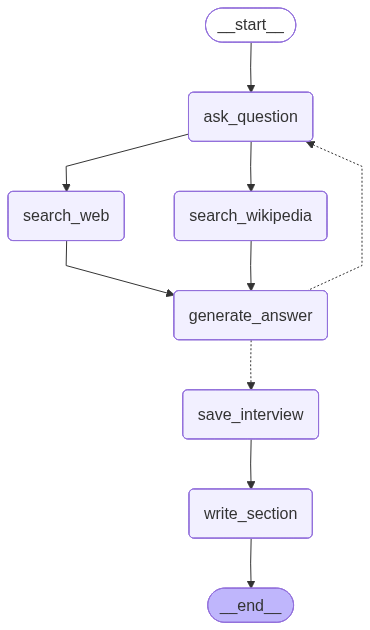

In [493]:
display(Image(interview_graph.get_graph().draw_mermaid_png()))

In [494]:
analyst

Analyst(name='Sophia Rodriguez', role='DevOps Engineer', affiliation='Cloud Services Provider', description='Sophia is a DevOps engineer who has deployed Langgraph in a cloud-based environment. She focuses on the practical aspects of implementing Langgraph for efficient resource allocation and monitoring.')

In [495]:
analyst.persona

'Name: Sophia Rodriguez\nRole: DevOps Engineer\nAffiliation: Cloud Services Provider\nDescription: Sophia is a DevOps engineer who has deployed Langgraph in a cloud-based environment. She focuses on the practical aspects of implementing Langgraph for efficient resource allocation and monitoring.\n'

In [496]:
thread = {"configurable": {"thread_id": "1"}}

In [497]:
from IPython.display import Markdown

In [498]:
messages = [HumanMessage("So you said you were writing an article on Langchain?")]

In [499]:
interview = interview_graph.invoke({"analyst": analyst, "messages": messages, "max_num_turns": 2}, thread)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph cloud-based environment implementation'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 3.000000 seconds
Retrying request to /openai/v1/chat/completions in 3.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 6.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


*******************************
search_query='Langgraph application performance optimization cloud resource allocation'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 31.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 32.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [500]:
Markdown(interview['sections'][0])

## Efficient Resource Allocation and Monitoring with LangGraph

### Summary

As a DevOps engineer, I have been exploring the LangGraph platform for efficient resource allocation and monitoring in cloud-based environments. LangGraph is an open-source library that enables multiple AI agents to collaborate on complex tasks by dividing responsibilities into specialized roles. This approach improves task efficiency, error management, and resource allocation. In this report, I will summarize the key features and benefits of LangGraph, as well as its deployment options and resource management capabilities.

LangGraph offers a range of deployment options, including Cloud, Hybrid, and Fully Self-Hosted. The Cloud option provides a fully managed and hosted environment, while the Hybrid option allows for SaaS control plane and self-hosted data plane. The Fully Self-Hosted option enables users to deploy LangGraph entirely on their own infrastructure.

LangGraph also provides advanced multi-agent coordination techniques, such as dynamic agent routing, memory and processing requirements, and agent configuration and connection setup. These features enable users to optimize resource allocation and improve task efficiency.

### Sources

[1] https://changelog.langchain.com/announcements/langgraph-platform-new-deployment-options-for-agent-infrastructure/
[2] https://blog.langchain.com/how-we-deployed-our-multi-agent-flow-to-langgraph-cloud-2/
[3] https://aws.amazon.com/blogs/machine-learning/build-multi-agent-systems-with-langgraph-and-amazon-bedrock/
[4] https://www.youtube.com/watch?v=T9hZ_C6oE4o
[5] https://www.langchain.com/langgraph
[6] https://blog.lamatic.ai/guides/langgraph-vs-langchain/
[7] https://latenode.com/blog/ai-frameworks-technical-infrastructure/langgraph-multi-agent-orchestration/langgraph-multi-agent-systems-complete-tutorial-examples/
[8] https://www.ijsat.org/papers/2025/1/2975.pdf
[9] https://www.rapidinnovation.io/post/ai-agents-in-langgraph

## third Workflow

In [501]:
from typing_extensions import TypedDict
from typing import List, Annotated
import operator
class ResearchGraphState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions
    sections: Annotated[list, operator.add] # Send() API key
    introduction: str # Introduction for the final report
    content: str # Content for the final report
    conclusion: str # Conclusion for the final report
    final_report: str # Final report
    
# class InterviewState(MessagesState):
#     max_num_turns: int # Number turns of conversation
#     context: Annotated[list, operator.add] # Source docs
#     analyst: Analyst # Analyst asking questions
#     interview: str # Interview transcript
#     sections: list # Final key we duplicate in outer state for Send() API

In [502]:
from langgraph.types import Send

In [503]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]


In [504]:
# def write_report(state:ResearchGraphState):
#     """_summary_

#     Args:
#         state (ResearchGraphState): _description_
#     """
#     pass

In [505]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [506]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [507]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [508]:
def write_introduction(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions]+[HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [509]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [510]:
def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [511]:
# Add nodes and edges 
builder = StateGraph(ResearchGraphState)
builder.add_node("create_analysts", create_analyst)
builder.add_node("human_feedback", human_feedback)
builder.add_node("conduct_interview", interview_builder.compile())
builder.add_node("write_report",write_report)
builder.add_node("write_introduction",write_introduction)
builder.add_node("write_conclusion",write_conclusion)
builder.add_node("finalize_report",finalize_report)

# Logic
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", initiate_all_interviews, ["create_analysts", "conduct_interview"])
builder.add_edge("conduct_interview", "write_report")
builder.add_edge("conduct_interview", "write_introduction")
builder.add_edge("conduct_interview", "write_conclusion")
builder.add_edge(["write_conclusion", "write_report", "write_introduction"], "finalize_report")
builder.add_edge("finalize_report", END)


In [512]:
memory = MemorySaver()

In [513]:
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

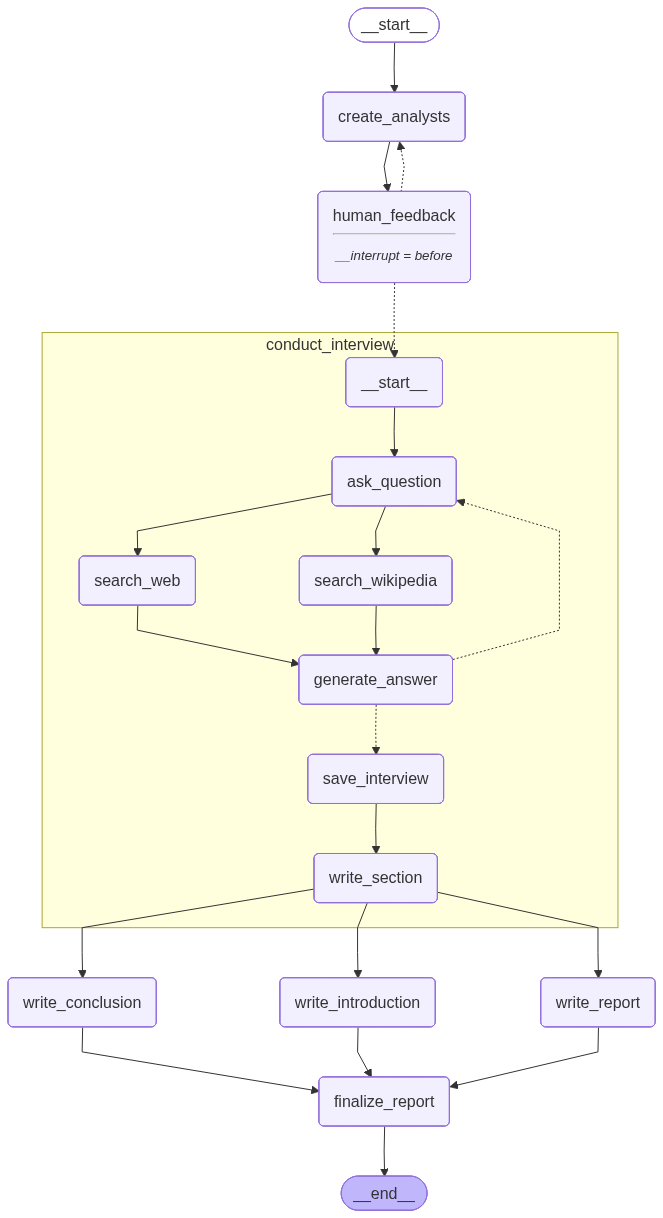

In [514]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [515]:
max_analysts = 3

In [516]:
topic = "How can generative help us to play the cricket?"

In [517]:
topic = "How can generative AI accelerate drug discovery?"

In [518]:
thread = {"configurable": {"thread_id": "1"}}

In [519]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 3.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Rachel Kim
Affiliation: Stanford University
Role: AI Researcher
Description: Dr. Kim focuses on the intersection of AI and biotechnology, with a particular interest in generative AI's potential to accelerate drug discovery.
--------------------------------------------------
Name: Dr. Liam Chen
Affiliation: Google Health
Role: Data Scientist
Description: Dr. Chen explores the application of machine learning in healthcare, including the use of generative AI in drug development.
--------------------------------------------------
Name: Dr. Sofia Patel
Affiliation: Pfizer
Role: Pharmaceutical Industry Expert
Description: Dr. Patel brings her expertise in the pharmaceutical industry to the analysis of generative AI's impact on drug discovery, highlighting potential challenges and opportunities.
--------------------------------------------------
Name: Dr. Ethan Hall
Affiliation: MIT
Role: AI Ethics Specialist
Description: Dr. Hall examines the ethical implications of using generativ

In [520]:
graph.update_state(thread, {"human_analyst_feedback":"along with the genetive ai in future tell me the future of indian team"}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0cd6b5-aaf4-6e69-8002-590d5e4c7db8'}}

In [521]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts}, thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 5.000000 seconds


Name: Dr. Rachel Kim
Affiliation: Stanford University
Role: AI Researcher
Description: Dr. Kim focuses on the intersection of AI and biotechnology, with a particular interest in generative AI's potential to accelerate drug discovery.
--------------------------------------------------
Name: Dr. Liam Chen
Affiliation: Google Health
Role: Data Scientist
Description: Dr. Chen explores the application of machine learning in healthcare, including the use of generative AI in drug development.
--------------------------------------------------
Name: Dr. Sofia Patel
Affiliation: Pfizer
Role: Pharmaceutical Industry Expert
Description: Dr. Patel brings her expertise in the pharmaceutical industry to the analysis of generative AI's impact on drug discovery, highlighting potential challenges and opportunities.
--------------------------------------------------
Name: Dr. Ethan Hall
Affiliation: MIT
Role: AI Ethics Specialist
Description: Dr. Hall examines the ethical implications of using generativ

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Rachel Kim
Affiliation: Stanford University
Role: AI Researcher
Description: Dr. Kim focuses on the intersection of AI and biotechnology, with a particular interest in generative AI's potential to accelerate drug discovery.
--------------------------------------------------
Name: Dr. Rohan Jain
Affiliation: Google Health
Role: Data Scientist
Description: Dr. Jain explores the applications of generative AI in healthcare, including its potential to improve drug discovery and development.
--------------------------------------------------
Name: Dr. Sofia Patel
Affiliation: Bloomberg Intelligence
Role: Biotech Analyst
Description: Dr. Patel analyzes the impact of generative AI on the biotech industry, including its potential to accelerate drug discovery and improve research efficiency.
--------------------------------------------------
Name: Dr. Liam Chen
Affiliation: MIT
Role: AI Ethics Specialist
Description: Dr. Chen examines the ethical implications of using generative AI in 

In [522]:
graph.update_state(thread, {"human_analyst_feedback":""}, as_node="human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0cd6b5-e353-62e0-8006-ba615d22a399'}}

In [523]:
graph.get_state(thread).next

('conduct_interview',
 'conduct_interview',
 'conduct_interview',
 'conduct_interview',
 'conduct_interview',
 'conduct_interview',
 'conduct_interview',
 'conduct_interview',
 'conduct_interview',
 'conduct_interview')

In [524]:
# Continue
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 3.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 3.000000 seconds
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
Retrying request to /openai/v1/chat/completions in 3.000000 seco

*******************************
search_query='generative AI drug discovery acceleration'


HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 413 Payload Too Large"


RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.1-8b-instant` in organization `org_01jsfaqfc0esxb795sbzrhm1aq` service tier `on_demand` on tokens per minute (TPM): Limit 6000, Used 5817, Requested 255. Please try again in 720ms. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [ ]:
from IPython.display import Markdown

In [ ]:
final_state = graph.get_state(thread)


In [ ]:
report = final_state.values.get('final_report')

In [ ]:
print(Markdown(report))

<IPython.core.display.Markdown object>


In [ ]:
print(report)

None
